# Risk & Returns Analytics — 5-Stock Portfolio

**Objective.** Analyse one year of daily OHLCV data for five synthetic stocks: price
history, returns, volatility, correlation, a Monte Carlo simulation of forward price
paths, and a portfolio Value-at-Risk (VaR) / Conditional VaR (CVaR) assessment.

**Data.** `data/raw/ohlc_5stocks_2025-2026.xlsx` — synthetic daily OHLCV data generated
via geometric Brownian motion (`src/synthetic_ohlc.py`, `scripts/generate_ohlc.py`).
There are no corporate actions in this dataset, so `close` is both the raw and the
(implicitly) split/dividend-adjusted price series.

**Methodology & assumptions**
- **Returns:** log returns for statistics/volatility/Monte Carlo (time-additive); simple
  returns when aggregating across stocks into the portfolio (cross-sectionally additive).
- **Annualisation:** 252 trading days/year throughout.
- **Portfolio:** equal-weight (20% each), $1,000,000 notional. Weights are a single
  variable, easy to change.
- **VaR / CVaR:** 1-day horizon, 95% and 99% confidence, reported as **positive loss
  magnitudes** in both % and $. Three methods for cross-validation: historical
  (empirical), parametric (variance-covariance, assumes normality), and Monte Carlo
  (10,000 jointly-simulated scenarios via Cholesky decomposition of the covariance
  matrix, preserving the historical correlation structure).
- **Monte Carlo (per-stock fan charts):** independent GBM, 10,000 paths, 1 year forward.
- **Reproducibility:** every simulation uses a fixed RNG seed.
- **Scope:** an in-sample risk snapshot over the available year of data, not an
  out-of-sample backtest — VaR/CVaR describe *this* estimated distribution, not a
  guarantee of future losses.

Run **Restart Kernel → Run All** before sharing; this notebook executes top-to-bottom
with no manual steps.

In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from data_io import load_ohlc_excel, to_wide_close
from returns import (
    log_returns,
    simple_returns,
    cumulative_returns,
    summary_stats,
    TRADING_DAYS_PER_YEAR,
)
from risk import (
    rolling_volatility,
    ewma_volatility,
    covariance_matrix,
    correlation_matrix,
    portfolio_returns,
    historical_var_cvar,
    parametric_var_cvar,
    monte_carlo_var_cvar,
)
from monte_carlo import simulate_gbm_paths, simulate_correlated_gbm_paths
from plotting import (
    CATEGORICAL,
    ticker_colors,
    style_axes,
    new_figure,
    diverging_cmap,
    STATUS_CRITICAL,
    STATUS_WARNING,
    TEXT_PRIMARY,
    TEXT_SECONDARY,
    TEXT_MUTED,
    SURFACE,
)

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [3]:
DATA_PATH = REPO_ROOT / "data" / "raw" / "ohlc_5stocks_2025-2026.xlsx"

long_df = load_ohlc_excel(DATA_PATH)
close = to_wide_close(long_df)
tickers = list(close.columns)
colors = ticker_colors(tickers)

print(f"Loaded {long_df['ticker'].nunique()} tickers, {close.shape[0]} trading days")
print(f"Date range: {close.index.min():%Y-%m-%d} -> {close.index.max():%Y-%m-%d}")
display(close.head())

Loaded 5 tickers, 252 trading days
Date range: 2025-07-17 -> 2026-07-03


,AHT,BRVE,CDRA,DLTA,EPSN
date,,,,,
2025-07-17,142.8200,59.8000,95.9400,34.0000,210.4300
2025-07-18,140.2800,59.9300,98.3600,32.8400,208.5000
2025-07-21,142.2100,60.9900,98.1000,32.2600,209.4100
2025-07-22,144.6500,60.3900,95.7100,33.1100,205.1800
2025-07-23,139.8100,60.3300,98.2800,34.2800,200.3000


## 1. Price History

Close price levels, plus a rebased-to-100 view since the five stocks trade at very different price scales (~$33-$210).

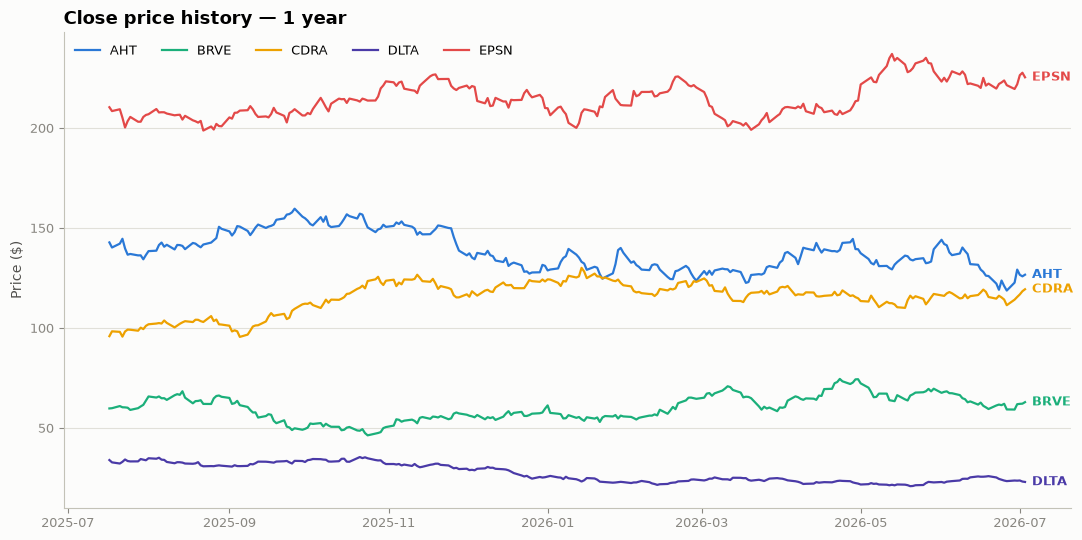

In [4]:
fig, ax = new_figure((11, 5.5))
for t in tickers:
    ax.plot(close.index, close[t], color=colors[t], linewidth=1.6, label=t)
    ax.annotate(
        t, xy=(close.index[-1], close[t].iloc[-1]), xytext=(5, 0),
        textcoords="offset points", color=colors[t], fontsize=9,
        va="center", fontweight="bold",
    )
ax.set_title("Close price history — 1 year", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Price ($)")
ax.legend(loc="upper left", frameon=False, ncols=5, fontsize=9)
fig.tight_layout()
plt.show()

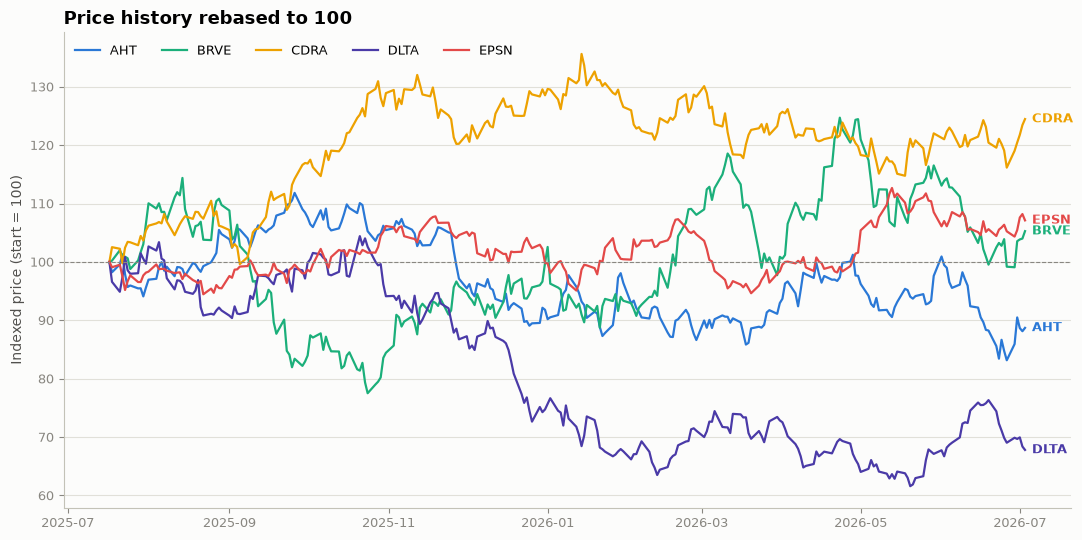

In [5]:
rebased = close / close.iloc[0] * 100

fig, ax = new_figure((11, 5.5))
for t in tickers:
    ax.plot(rebased.index, rebased[t], color=colors[t], linewidth=1.6, label=t)
    ax.annotate(
        t, xy=(rebased.index[-1], rebased[t].iloc[-1]), xytext=(5, 0),
        textcoords="offset points", color=colors[t], fontsize=9,
        va="center", fontweight="bold",
    )
ax.axhline(100, color=TEXT_MUTED, linewidth=0.8, linestyle="--")
ax.set_title("Price history rebased to 100", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Indexed price (start = 100)")
ax.legend(loc="upper left", frameon=False, ncols=5, fontsize=9)
fig.tight_layout()
plt.show()

## 2. Returns

Log returns are used for all statistics below (time-additive); simple returns are computed here too and reserved for portfolio aggregation in Section 6.

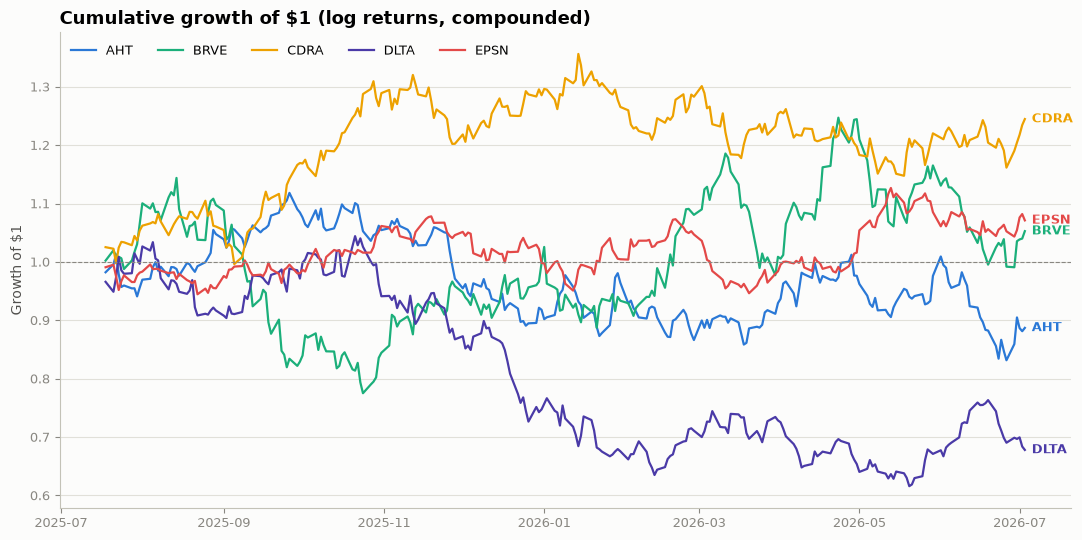

In [6]:
log_rets = log_returns(close)
simple_rets = simple_returns(close)

cum_log = cumulative_returns(log_rets, log=True)

fig, ax = new_figure((11, 5.5))
for t in tickers:
    ax.plot(cum_log.index, cum_log[t], color=colors[t], linewidth=1.6, label=t)
    ax.annotate(
        t, xy=(cum_log.index[-1], cum_log[t].iloc[-1]), xytext=(5, 0),
        textcoords="offset points", color=colors[t], fontsize=9,
        va="center", fontweight="bold",
    )
ax.axhline(1.0, color=TEXT_MUTED, linewidth=0.8, linestyle="--")
ax.set_title("Cumulative growth of $1 (log returns, compounded)", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", frameon=False, ncols=5, fontsize=9)
fig.tight_layout()
plt.show()

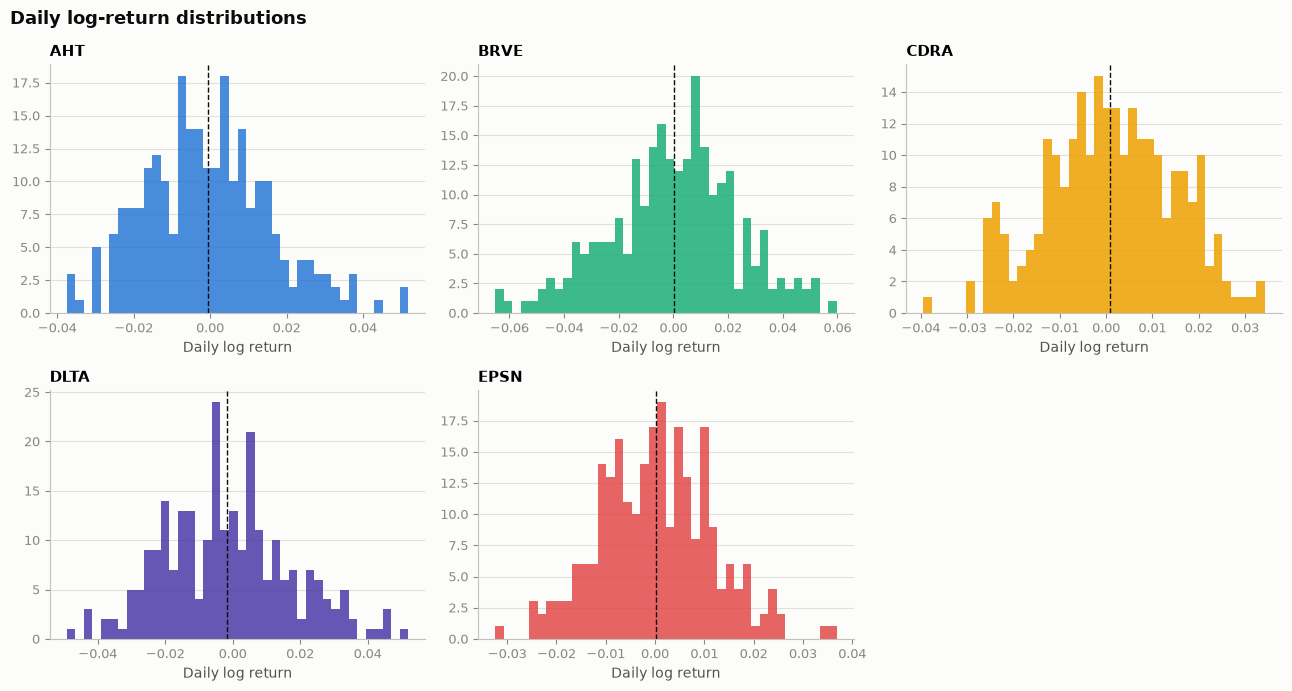

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), facecolor=SURFACE)
axes_flat = axes.flatten()
for i, t in enumerate(tickers):
    ax = axes_flat[i]
    style_axes(ax)
    ax.hist(log_rets[t], bins=40, color=colors[t], alpha=0.85)
    ax.axvline(log_rets[t].mean(), color=TEXT_PRIMARY, linewidth=1.0, linestyle="--")
    ax.set_title(t, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel("Daily log return")
axes_flat[-1].set_visible(False)
fig.suptitle("Daily log-return distributions", x=0.01, ha="left", fontsize=13, fontweight="bold", color=TEXT_PRIMARY)
fig.tight_layout()
plt.show()

In [8]:
stats_log = summary_stats(log_rets, log=True)
stats_display = stats_log.copy()
stats_display["ann_return"] = (stats_display["ann_return"] * 100).round(2)
stats_display["ann_vol"] = (stats_display["ann_vol"] * 100).round(2)
stats_display = stats_display.rename(columns={"ann_return": "ann_return_%", "ann_vol": "ann_vol_%"})
display(stats_display[["ann_return_%", "ann_vol_%", "sharpe", "skew", "kurtosis"]].round(2))

,ann_return_%,ann_vol_%,sharpe,skew,kurtosis
ticker,,,,,
AHT,-12.0400,26.3000,-0.4600,0.3900,0.1800
BRVE,5.1500,36.9900,0.1400,-0.1600,0.0100
CDRA,21.9700,22.1100,0.9900,-0.1000,-0.4000
DLTA,-39.0200,29.9300,-1.3000,0.2500,-0.1200
EPSN,6.9000,18.0500,0.3800,0.1600,0.1000


## 3. Volatility

Annualised volatility by stock, plus rolling (21d/63d) and EWMA (λ=0.94, RiskMetrics-style) estimates to show how it evolves through the year.

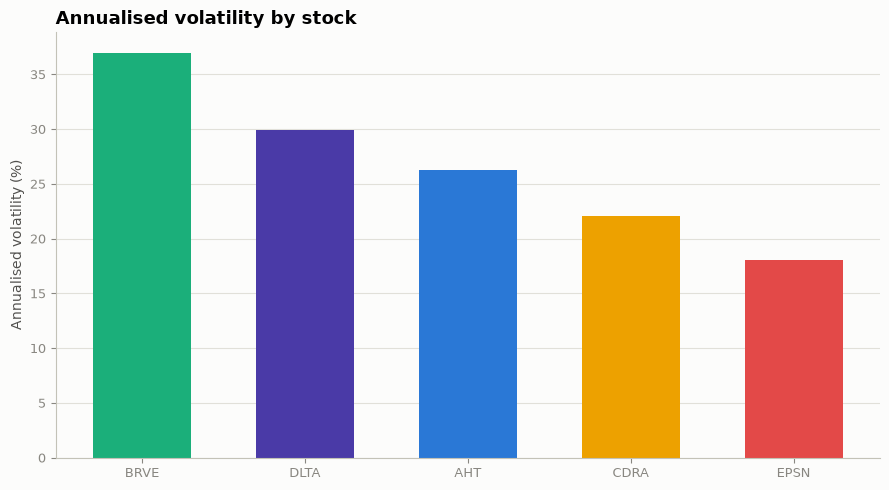

In [9]:
fig, ax = new_figure((9, 5))
order = stats_log["ann_vol"].sort_values(ascending=False).index
bar_colors = [colors[t] for t in order]
ax.bar(order, stats_log.loc[order, "ann_vol"] * 100, color=bar_colors, width=0.6)
ax.set_title("Annualised volatility by stock", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Annualised volatility (%)")
fig.tight_layout()
plt.show()

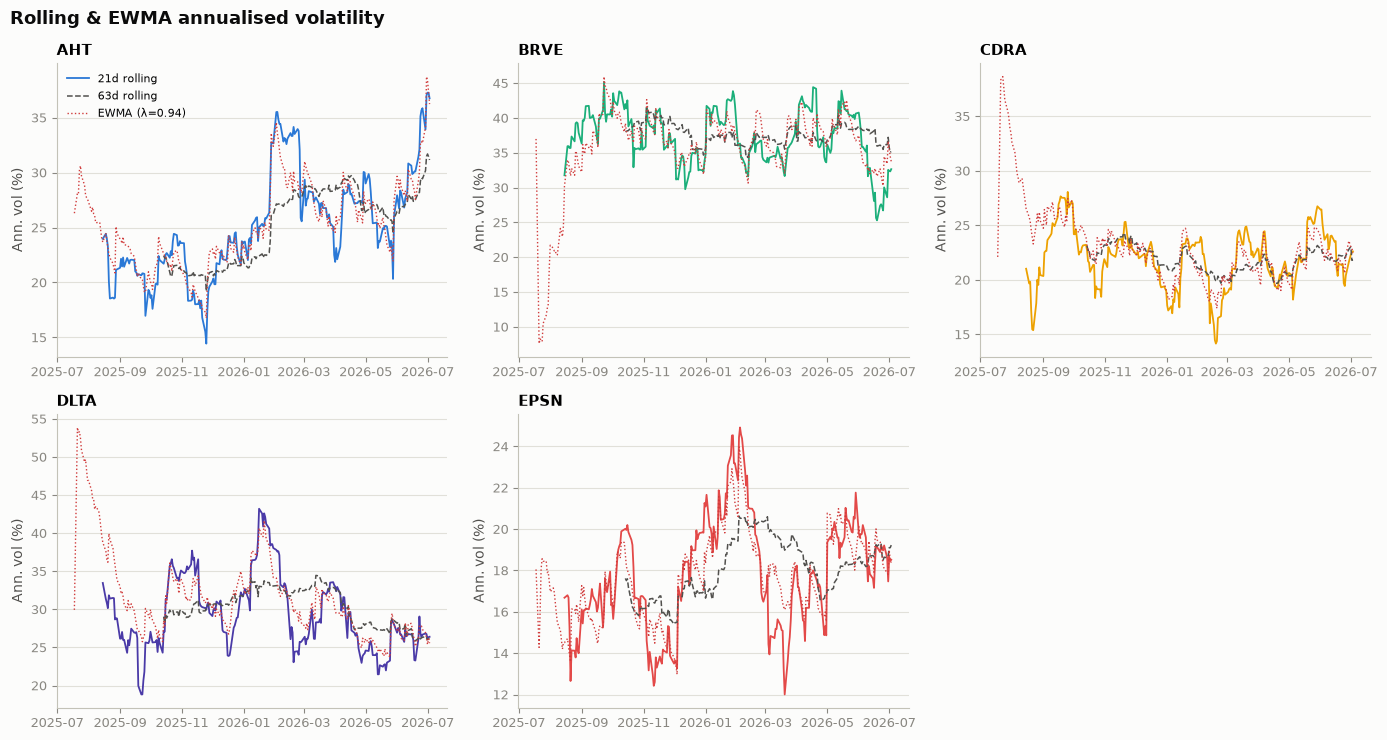

In [10]:
roll_21 = rolling_volatility(log_rets, window=21)
roll_63 = rolling_volatility(log_rets, window=63)
ewma_vol = ewma_volatility(log_rets)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), facecolor=SURFACE)
axes_flat = axes.flatten()
for i, t in enumerate(tickers):
    ax = axes_flat[i]
    style_axes(ax)
    ax.plot(roll_21.index, roll_21[t] * 100, color=colors[t], linewidth=1.3, label="21d rolling")
    ax.plot(roll_63.index, roll_63[t] * 100, color=TEXT_SECONDARY, linewidth=1.1, linestyle="--", label="63d rolling")
    ax.plot(ewma_vol.index, ewma_vol[t] * 100, color=STATUS_CRITICAL, linewidth=1.0, linestyle=":", label="EWMA (λ=0.94)")
    ax.set_title(t, loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel("Ann. vol (%)")
    if i == 0:
        ax.legend(loc="upper left", frameon=False, fontsize=8)
axes_flat[-1].set_visible(False)
fig.suptitle("Rolling & EWMA annualised volatility", x=0.01, ha="left", fontsize=13, fontweight="bold", color=TEXT_PRIMARY)
fig.tight_layout()
plt.show()

## 4. Correlation

Return correlation drives diversification and joint tail risk — it feeds directly into the Monte Carlo portfolio VaR in Section 7.

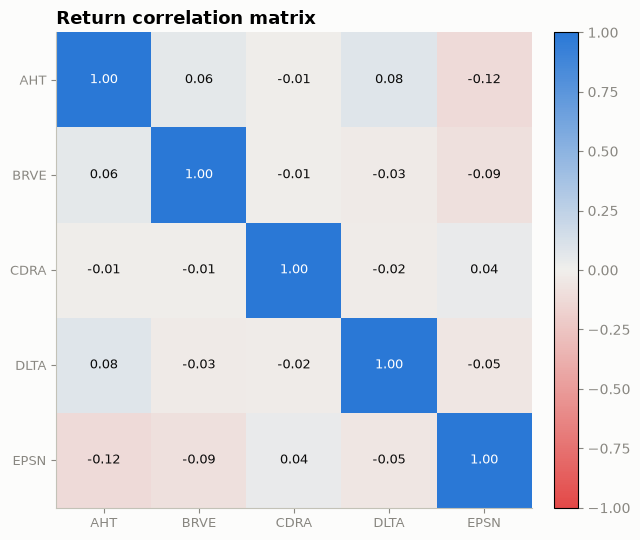

In [11]:
corr = correlation_matrix(log_rets)

fig, ax = new_figure((6.5, 5.5))
ax.grid(False)
im = ax.imshow(corr.loc[tickers, tickers], cmap=diverging_cmap(), vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        val = corr.loc[tickers[i], tickers[j]]
        ax.text(
            j, i, f"{val:.2f}", ha="center", va="center",
            color="white" if abs(val) > 0.6 else TEXT_PRIMARY, fontsize=9,
        )
ax.set_title("Return correlation matrix", loc="left", fontsize=13, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors=TEXT_MUTED)
fig.tight_layout()
plt.show()

In [12]:
cov_annual_log = covariance_matrix(log_rets, annualize=True)
display(cov_annual_log.round(4))

,AHT,BRVE,CDRA,DLTA,EPSN
AHT,0.0692,0.0059,-0.0006,0.0063,-0.0056
BRVE,0.0059,0.1368,-0.0011,-0.0031,-0.0060
CDRA,-0.0006,-0.0011,0.0489,-0.0012,0.0014
DLTA,0.0063,-0.0031,-0.0012,0.0896,-0.0029
EPSN,-0.0056,-0.0060,0.0014,-0.0029,0.0326


## 5. Monte Carlo Simulation — Per-Stock Price Paths

Independent GBM simulation per stock, using each stock's own annualised drift and
volatility estimated in Section 2, projected 1 year (252 trading days) forward with
10,000 paths.

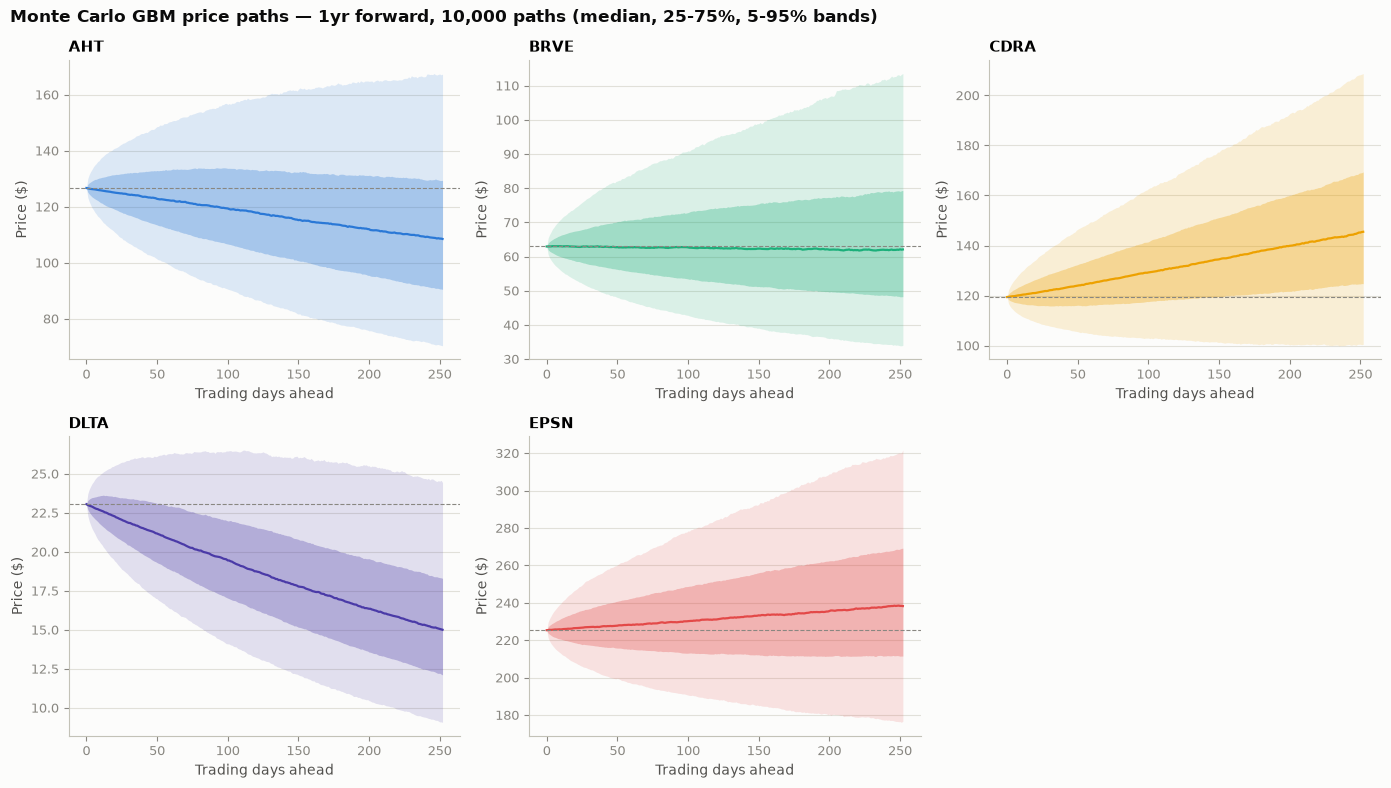

In [13]:
N_PATHS = 10_000
N_DAYS_FORWARD = TRADING_DAYS_PER_YEAR

mc_paths = {}
for i, t in enumerate(tickers):
    s0 = close[t].iloc[-1]
    mu = stats_log.loc[t, "ann_return"]
    sigma = stats_log.loc[t, "ann_vol"]
    mc_paths[t] = simulate_gbm_paths(
        s0=s0, mu_annual=mu, sigma_annual=sigma,
        n_days=N_DAYS_FORWARD, n_paths=N_PATHS, seed=1000 + i,
    )

fig, axes = plt.subplots(2, 3, figsize=(14, 8), facecolor=SURFACE)
axes_flat = axes.flatten()
horizon = np.arange(N_DAYS_FORWARD + 1)
percentiles = [5, 25, 50, 75, 95]
for i, t in enumerate(tickers):
    ax = axes_flat[i]
    style_axes(ax)
    paths = mc_paths[t]
    pct = np.percentile(paths, percentiles, axis=1)
    ax.fill_between(horizon, pct[0], pct[4], color=colors[t], alpha=0.15, linewidth=0)
    ax.fill_between(horizon, pct[1], pct[3], color=colors[t], alpha=0.30, linewidth=0)
    ax.plot(horizon, pct[2], color=colors[t], linewidth=1.6)
    ax.axhline(close[t].iloc[-1], color=TEXT_MUTED, linewidth=0.8, linestyle="--")
    ax.set_title(t, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel("Trading days ahead")
    ax.set_ylabel("Price ($)")
axes_flat[-1].set_visible(False)
fig.suptitle(
    f"Monte Carlo GBM price paths — 1yr forward, {N_PATHS:,} paths (median, 25-75%, 5-95% bands)",
    x=0.01, ha="left", fontsize=12, fontweight="bold", color=TEXT_PRIMARY,
)
fig.tight_layout()
plt.show()

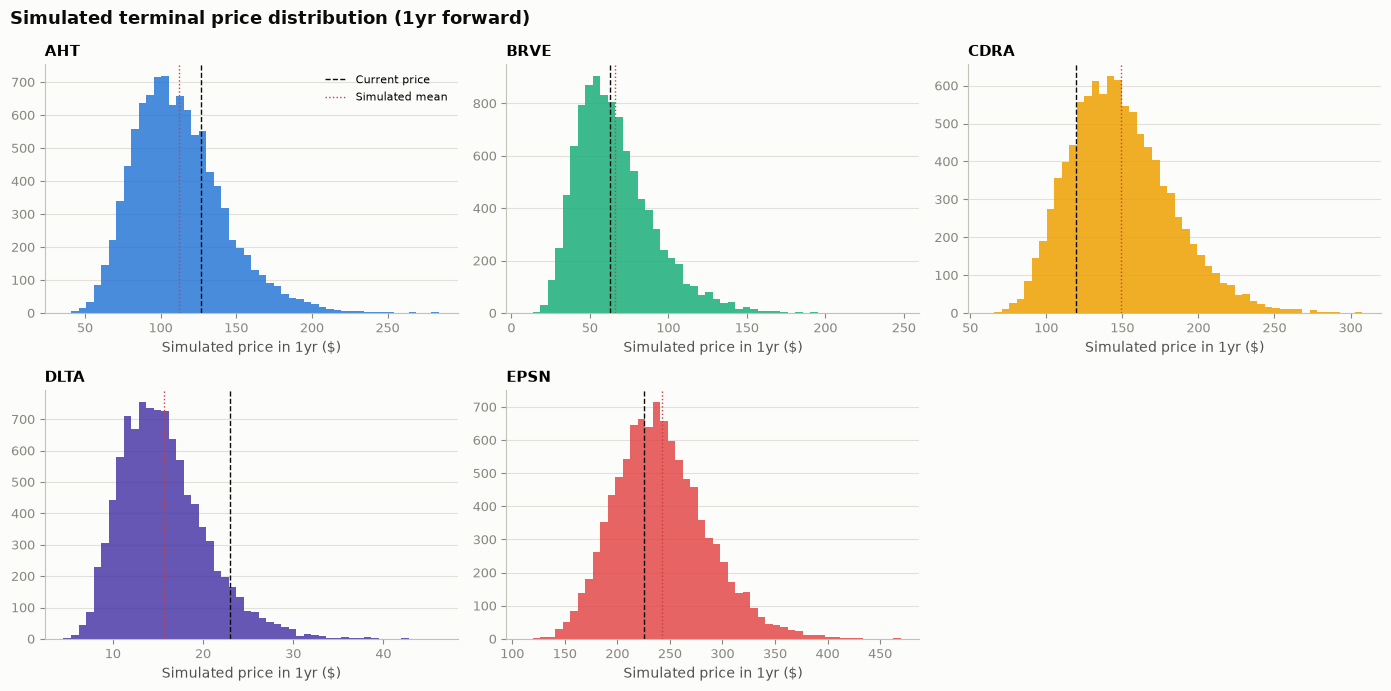

,current_price,sim_mean,sim_p05,sim_p50,sim_p95
ticker,,,,,
AHT,126.6800,112.2100,70.3500,108.4900,167.3400
BRVE,62.9500,66.2600,34.0000,62.0700,113.5500
CDRA,119.4100,148.8700,100.4700,145.4900,208.7400
DLTA,23.0500,15.6400,9.0800,15.0100,24.4400
EPSN,225.3900,242.2700,176.6900,238.2600,321.6700


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), facecolor=SURFACE)
axes_flat = axes.flatten()
mc_summary_rows = []
for i, t in enumerate(tickers):
    ax = axes_flat[i]
    style_axes(ax)
    terminal = mc_paths[t][-1]
    ax.hist(terminal, bins=50, color=colors[t], alpha=0.85)
    ax.axvline(close[t].iloc[-1], color=TEXT_PRIMARY, linewidth=1.0, linestyle="--", label="Current price")
    ax.axvline(terminal.mean(), color=STATUS_CRITICAL, linewidth=1.0, linestyle=":", label="Simulated mean")
    ax.set_title(t, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel("Simulated price in 1yr ($)")
    if i == 0:
        ax.legend(loc="upper right", frameon=False, fontsize=8)
    mc_summary_rows.append({
        "ticker": t,
        "current_price": close[t].iloc[-1],
        "sim_mean": terminal.mean(),
        "sim_p05": np.percentile(terminal, 5),
        "sim_p50": np.percentile(terminal, 50),
        "sim_p95": np.percentile(terminal, 95),
    })
axes_flat[-1].set_visible(False)
fig.suptitle("Simulated terminal price distribution (1yr forward)", x=0.01, ha="left", fontsize=13, fontweight="bold", color=TEXT_PRIMARY)
fig.tight_layout()
plt.show()

mc_summary = pd.DataFrame(mc_summary_rows).set_index("ticker").round(2)
display(mc_summary)

## 6. Portfolio Construction

Equal-weight (20% each) portfolio on a $1,000,000 notional. Portfolio returns are the weighted sum of **simple** returns (correct cross-sectional aggregation).

AHT    0.2000
BRVE   0.2000
CDRA   0.2000
DLTA   0.2000
EPSN   0.2000
Name: weight, dtype: float64

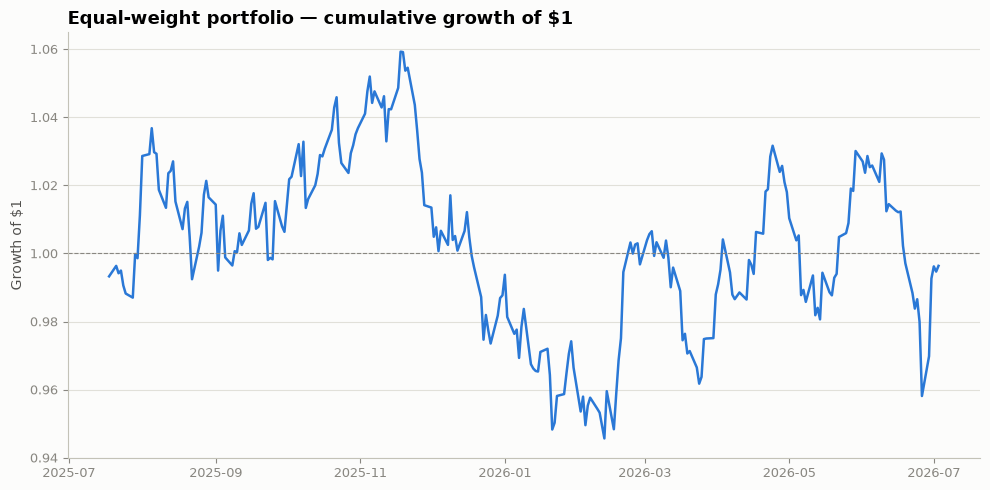

Portfolio notional: $1,000,000
Annualised return: 0.36%
Annualised volatility: 12.05%
Sharpe (rf=0%): 0.03


In [15]:
PORTFOLIO_VALUE = 1_000_000.0
weights = pd.Series(1.0 / len(tickers), index=tickers)
display(weights.rename("weight"))

port_simple = portfolio_returns(simple_rets, weights)
port_cum = (1.0 + port_simple).cumprod()

fig, ax = new_figure((10, 5))
ax.plot(port_cum.index, port_cum, color=CATEGORICAL[0], linewidth=1.8)
ax.axhline(1.0, color=TEXT_MUTED, linewidth=0.8, linestyle="--")
ax.set_title("Equal-weight portfolio — cumulative growth of $1", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("Growth of $1")
fig.tight_layout()
plt.show()

port_ann_return = (1 + port_simple.mean()) ** TRADING_DAYS_PER_YEAR - 1
port_ann_vol = port_simple.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)
port_sharpe = port_ann_return / port_ann_vol
print(f"Portfolio notional: ${PORTFOLIO_VALUE:,.0f}")
print(f"Annualised return: {port_ann_return:.2%}")
print(f"Annualised volatility: {port_ann_vol:.2%}")
print(f"Sharpe (rf=0%): {port_sharpe:.2f}")

## 7. Portfolio VaR & CVaR

1-day Value-at-Risk and Conditional VaR (Expected Shortfall) at 95% and 99% confidence,
via three methods:
- **Historical** — empirical quantile of realised portfolio returns.
- **Parametric** — variance-covariance method, assumes normally distributed returns.
- **Monte Carlo** — empirical quantile of 10,000 *jointly* simulated 1-day returns, drawn
  from a correlated GBM step (Cholesky decomposition of the annualised log-return
  covariance matrix), so the simulated tail respects the historical correlation structure.

In [16]:
CONFIDENCE_LEVELS = [0.95, 0.99]
N_SIMS = 10_000

mu_annual_vec = stats_log["ann_return"]

mc_price_paths_1d = simulate_correlated_gbm_paths(
    s0=close.iloc[-1], mu_annual=mu_annual_vec, cov_annual=cov_annual_log,
    n_days=1, n_paths=N_SIMS, seed=2026,
)
mc_simple_rets_1d = pd.DataFrame(
    {t: mc_price_paths_1d[t][1] / mc_price_paths_1d[t][0] - 1.0 for t in tickers}
)
mc_port_rets = portfolio_returns(mc_simple_rets_1d, weights)

var_rows = []
var_results = {}
for conf in CONFIDENCE_LEVELS:
    hist = historical_var_cvar(port_simple, conf, PORTFOLIO_VALUE)
    param = parametric_var_cvar(port_simple, conf, PORTFOLIO_VALUE)
    mc = monte_carlo_var_cvar(mc_port_rets.to_numpy(), conf, PORTFOLIO_VALUE)
    var_results[conf] = {"historical": hist, "parametric": param, "monte_carlo": mc}
    for res in (hist, param, mc):
        var_rows.append({
            "confidence": f"{conf:.0%}", "method": res.method,
            "VaR_%": res.var_pct * 100, "VaR_$": res.var_dollar,
            "CVaR_%": res.cvar_pct * 100, "CVaR_$": res.cvar_dollar,
        })

var_table = pd.DataFrame(var_rows).set_index(["confidence", "method"]).round(2)
display(var_table)

VaR_%       VaR_$  CVaR_%      CVaR_$
confidence method                                            
95%        historical  1.2700 12,673.5300  1.6000 16,023.2700
           parametric  1.2500 12,471.6800  1.5600 15,643.5800
           monte_carlo 1.2300 12,258.4200  1.5200 15,192.6600
99%        historical  1.8100 18,130.3000  2.0100 20,059.4600
           parametric  1.7600 17,644.7900  2.0200 20,217.0700
           monte_carlo 1.6900 16,937.1800  1.9500 19,541.3100

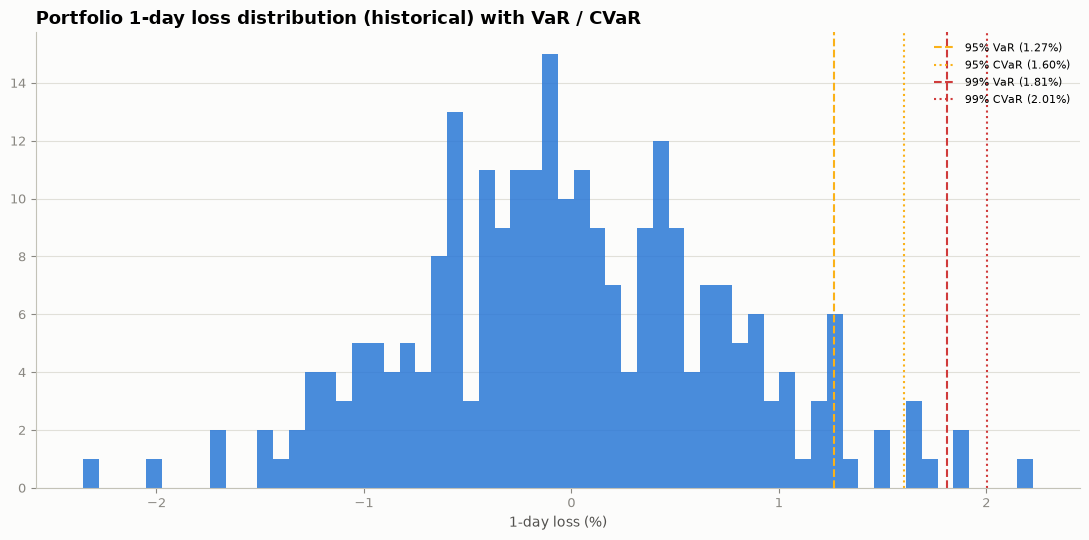

In [17]:
fig, ax = new_figure((11, 5.5))
losses_pct = -port_simple * 100
ax.hist(losses_pct, bins=60, color=CATEGORICAL[0], alpha=0.85)

var_95, var_99 = var_results[0.95]["historical"], var_results[0.99]["historical"]
ax.axvline(var_95.var_pct * 100, color=STATUS_WARNING, linewidth=1.5, linestyle="--", label=f"95% VaR ({var_95.var_pct:.2%})")
ax.axvline(var_95.cvar_pct * 100, color=STATUS_WARNING, linewidth=1.5, linestyle=":", label=f"95% CVaR ({var_95.cvar_pct:.2%})")
ax.axvline(var_99.var_pct * 100, color=STATUS_CRITICAL, linewidth=1.5, linestyle="--", label=f"99% VaR ({var_99.var_pct:.2%})")
ax.axvline(var_99.cvar_pct * 100, color=STATUS_CRITICAL, linewidth=1.5, linestyle=":", label=f"99% CVaR ({var_99.cvar_pct:.2%})")
ax.set_title("Portfolio 1-day loss distribution (historical) with VaR / CVaR", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("1-day loss (%)")
ax.legend(loc="upper right", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 8. Summary

**Caveats:** in-sample estimates only (mean/vol/correlation assumed stationary over the
horizon); the parametric method understates fat tails/skew relative to historical and
Monte Carlo; no transaction costs, slippage, or intraday risk are modelled — this is a
risk snapshot, not a backtest.

In [18]:
print("Summary of key figures")
print("=" * 40)
print(f"Analysis period: {close.index.min():%Y-%m-%d} -> {close.index.max():%Y-%m-%d} ({len(close)} trading days)")
print(f"Portfolio: equal-weight, {len(tickers)} stocks, ${PORTFOLIO_VALUE:,.0f} notional")
print(f"Portfolio annualised return / vol: {port_ann_return:.2%} / {port_ann_vol:.2%} (Sharpe {port_sharpe:.2f})")
print()
print("1-day VaR / CVaR (historical method):")
print(f"  95%: VaR ${var_95.var_dollar:,.0f} ({var_95.var_pct:.2%})  |  CVaR ${var_95.cvar_dollar:,.0f} ({var_95.cvar_pct:.2%})")
print(f"  99%: VaR ${var_99.var_dollar:,.0f} ({var_99.var_pct:.2%})  |  CVaR ${var_99.cvar_dollar:,.0f} ({var_99.cvar_pct:.2%})")

Summary of key figures
Analysis period: 2025-07-17 -> 2026-07-03 (252 trading days)
Portfolio: equal-weight, 5 stocks, $1,000,000 notional
Portfolio annualised return / vol: 0.36% / 12.05% (Sharpe 0.03)

1-day VaR / CVaR (historical method):
  95%: VaR $12,674 (1.27%)  |  CVaR $16,023 (1.60%)
  99%: VaR $18,130 (1.81%)  |  CVaR $20,059 (2.01%)
